# Vec-file based analysis (raster + PSTH)

Description: This notebook computes raster plots and PSTHs for any recording whose stimulus is described by a `.vec` file. It is a generic "classic" analysis: spikes are split into stimulus sequences, repetitions of the same sequence are stacked into a raster, and a PSTH (firing rate over time) is computed for every cell × sequence type.

**How the vec file must be formatted**

The vec file's **last column** holds a *sequence key* for every trigger. A key is read as:

`<sequence-type digits>` + `<repetition digits>`

- The leading digits identify the **sequence type** (e.g. a grating direction).
- The last `n_digit_for_rep` digits (4 by default) give the **repetition number**.

Example with `n_digit_for_rep = 4`: key `10002` → sequence type `1`, repetition `0002`. Repetitions do not need to be sorted; they are stacked in the raster in their order of appearance in the vec file.

**Requirements**
- Run the preprocessing notebook first (you need the triggers and the sorted-neurons `.pkl` files).
- Configure your experiment in `./params.py` (this notebook uses: `exp`, `fs`, `root`, `recording_names`, `triggers_directory`, `output_directory`).

**Execution time**: a few minutes (scales with the number of cells).

In [1]:
%reload_ext autoreload
%autoreload 2

# standard packages
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# project packages
import params
import utils


-------- Creating all paths ---------

- phy (.GUI): found automatically
    /media/idv-s8/SSD Storage/20260702_Brid_Vs_Retina_Vs_Strychnine_1_test_pipeline/RAW_Files/20260702_00_SWN_30Hz/20260702_00_SWN_30Hz.GUI
- "output" path already exists
- "triggers" path already exists


/home/idv-s8/anaconda3/envs/std_analysis_pipeline/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

- The values used here come from your `params.py` file. Only change them by hand for a one-off run (e.g. debugging).
- You will be asked to type the **number** of the recording and of the vec file to analyse.
- **Mandatory for every run.**

In [2]:
%%time

# ---- Choose the recording ----------------------------------------------
# Recordings are listed in params.py. Type the number of the one to analyse.
print("Available recordings:")
for number, name in enumerate(params.recording_names):
    print(f"\t{number} --> {name}")
recording_number = int(input("\nRecording number : "))
recording_name = params.recording_names[recording_number]
print(f"Selected recording: {recording_name}\n")

# Folder where this analysis (dictionaries + figures) will be saved
analysis_directory = os.path.normpath(
    os.path.join(params.output_directory, f"Vec_Analysis_rec_{recording_number}")
)
os.makedirs(analysis_directory, exist_ok=True)

# ---- Choose and load the vec (stimulus) file ---------------------------
# Stimulus files live in params.stim_directory (RessourcesAndTools/StandardVec), like the
# other analyses. Set the one you most often analyse as the default; you can always pick
# another when prompted (press Enter to accept the default).
default_vec_file = "01_DG_50hz_10reps_8dir_2sT_std.vec"
vec_path = utils.find_vec_file(default_vec_file, params.stim_directory)

# The vec's last column is the sequence key of each trigger.
# The first line is a header (not a trigger), so we drop it.
vec = np.loadtxt(vec_path)[1:, :]
vec_keys = vec[:, -1]
print(f"Vec file length (number of triggers): {len(vec_keys)}")

# ---- Load triggers (stimulus onset times, in seconds) ------------------
trig_data = utils.load_obj(
    os.path.join(
        params.triggers_directory, f"{params.exp}_{recording_name}_triggers.pkl"
    )
)
stim_onsets = trig_data["indices"] / params.fs
print(f"Total triggers number : {len(stim_onsets)}")
print(f"Triggers type loaded : {trig_data['trigger_type']}")

# ---- Load spikes of every sorted neuron for this recording -------------
spike_trains = utils.load_obj(
    os.path.join(params.output_directory, f"{params.exp}_fullexp_neurons_data.pkl")
)
cells = list(spike_trains.keys())
spike_times = {cell: spike_trains[cell][recording_name] for cell in cells}
print(f"\nTotal : {len(cells)} neurons loaded")
print(f"Cell ids:\n{cells}")

Available recordings:
	0 --> 20260702_00_SWN_30Hz
	1 --> 20260702_01_SWN_30Hz
	2 --> 20260702_02_chirp_50Hz
	3 --> 20260702_03_DG_2sT_10rep_8dir_50Hz
	4 --> 20260702_04_barcode_3dir_50Hz
	5 --> 20260702_05_black_eagle_CTL_40Hz
	6 --> 20260702_05_black_eagle_CTL_40Hz_part2
	7 --> 20260702_06_SWN_drug_being_added_30Hz
	8 --> 20260702_07_black_eagle_strychnine_40Hz
	9 --> 20260702_08_SWN_drug_being_removed_30Hz
	10 --> 20260702_09_black_eagle_post_strychnine_CTL_40Hz
Selected recording: 20260702_02_chirp_50Hz


Stimulus files in ./RessourcesAndTools/StandardVec:
    0 : 01_DG_50hz_10reps_8dir_2sT_std.vec   <- default
    1 : 20250512_4_SWN_48pixCh_6pixShift_30Hz_MEA2.vec
    2 : DG_50hZ_8reps_8dir_2sT.vec
    3 : DG_50hZ_8reps_8dir_2sT_std.vec
    4 : Euler_50Hz_20reps_1024x768pix_std.vec
Using stimulus file: Euler_50Hz_20reps_1024x768pix_std.vec

Vec file length (number of triggers): 32250
Total triggers number : 32400
Triggers type loaded : visual

Total : 210 neurons loaded
Cell ids:
[

In [3]:
# ---- Debug option: limit the number of cells ---------------------------
# To test quickly, process only the first few cells. Set to None to use all.
n_cells_for_debug = None  # e.g. 5 for a quick test, None for all cells

if n_cells_for_debug is not None:
    cells = cells[:n_cells_for_debug]
    print(f"DEBUG: processing only the first {len(cells)} cells")

## Compute rasters and PSTHs

- For every cell and every sequence type, this splits the spikes into repetitions, stacks them into a raster, and computes the PSTH.
- **Requirements**: "Load data" cell run.
- **Execution time**: a few minutes (scales with the number of cells).

In [4]:
%%time

# ---- Inputs ------------------------------------------------------------
bin_size = 0.025     # PSTH bin width, in seconds
n_digit_for_rep = 4  # number of trailing digits of a vec key that encode the repetition number
recompute = True     # True = compute from spikes ; False = load previously saved results
save_data = True     # save the computed dictionaries to disk

# ---- Output file names -------------------------------------------------
sequence_dict_file = os.path.join(analysis_directory, f"{recording_name}_dict.pkl")
triggers_file = os.path.join(analysis_directory, f"{recording_name}_Sorted_triggers.pkl")
spikes_file = os.path.join(analysis_directory, f"{recording_name}_Sorted_Spikes.pkl")

# ---- Compute or load ---------------------------------------------------
if recompute or not os.path.exists(sequence_dict_file):
    print("Splitting spikes into sequences for each cell...")
    (
        spikes_per_sequence_dict,
        triggers_per_repetition,
        spikes_per_repetition,
    ) = utils.build_spikes_per_sequence_dict(
        cells,
        spike_times,
        stim_onsets,
        vec_keys,
        bin_size=bin_size,
        n_digit_for_rep=n_digit_for_rep,
    )
    if save_data:
        utils.save_obj(spikes_per_sequence_dict, sequence_dict_file)
        utils.save_obj(triggers_per_repetition, triggers_file)
        utils.save_obj(spikes_per_repetition, spikes_file)
        print(f"Saved results in {analysis_directory}")
else:
    spikes_per_sequence_dict = utils.load_obj(sequence_dict_file)
    print(f"Loaded previously computed results from {sequence_dict_file}")

print("----- Done -----")

Splitting spikes into sequences for each cell...


100%|██████████| 210/210 [00:00<00:00, 609.78it/s]


Saved results in /media/idv-s8/SSD Storage/20260702_Brid_Vs_Retina_Vs_Strychnine_1_test_pipeline/Analysis/Vec_Analysis_rec_2
----- Done -----
CPU times: user 414 ms, sys: 23.5 ms, total: 437 ms
Wall time: 444 ms


In [5]:
# Peek at the result for one cell to understand its structure:
#   spikes_per_sequence_dict[cell][sequence_key] -> {"raster", "psth", "triggers"}
example_cell = cells[0]
print(f"Cell {example_cell} sequence types: {sorted(spikes_per_sequence_dict[example_cell])}")

example_sequence_key = sorted(spikes_per_sequence_dict[example_cell])[0]
example = spikes_per_sequence_dict[example_cell][example_sequence_key]
print(f"\nSequence '{example_sequence_key}' contains:")
print(f"  raster   : {len(example['raster'])} repetitions")
print(f"  psth     : {len(example['psth'])} time bins")
print(f"  duration : {example['triggers']['rng'][1]:.2f} s")

Cell 1 sequence types: ['1']

Sequence '1' contains:
  raster   : 20 repetitions
  psth     : 1280 time bins
  duration : 32.00 s


## Plot and save all figures

- Saves one raster + PSTH figure per cell × sequence type into the analysis folder.
- Figures already on disk are skipped, so this cell is safe to re-run.
- **Requirements**: "Compute rasters and PSTHs" cell run.
- **Execution time**: about 10 s per figure; can be long for many cells.

In [6]:
%%time

# ---- Inputs ------------------------------------------------------------
color = "#B85A8F"          # plot color (any matplotlib color name or hex code)
smoothing = 0.4            # PSTH smoothing, between 0 (none) and 1 (very smooth)
clusters_as_folder = True  # True: one folder per cell ; False: one folder per sequence
fontsize = 18              # base font size for titles and labels

# Plot and save a raster + PSTH figure for every cell x sequence type.
utils.save_sequence_figures(
    spikes_per_sequence_dict,
    analysis_directory,
    color=color,
    smoothing=smoothing,
    clusters_as_folder=clusters_as_folder,
    fontsize=fontsize,
)
print(f"Figures saved in {analysis_directory}")

100%|██████████| 210/210 [00:58<00:00,  3.56it/s]

Figures saved in /media/idv-s8/SSD Storage/20260702_Brid_Vs_Retina_Vs_Strychnine_1_test_pipeline/Analysis/Vec_Analysis_rec_2
CPU times: user 58.3 s, sys: 753 ms, total: 59.1 s
Wall time: 59 s


## Customize a single plot

The batch cell above calls `utils.plot_sequence` for every figure. To experiment with the look, draw a single sequence here and re-use what you like above.

Because `plot_sequence` draws into axes **you** create, this is also where you control **figure size, titles, and layout** — just make your own figure first.

You also have direct access to the raw data of each sequence:
- `sequence["raster"]` — list of spike-time arrays, one per repetition
- `sequence["psth"]` — mean spike count per time bin
- `sequence["triggers"]["rng"]` — `(0, duration_in_seconds)`

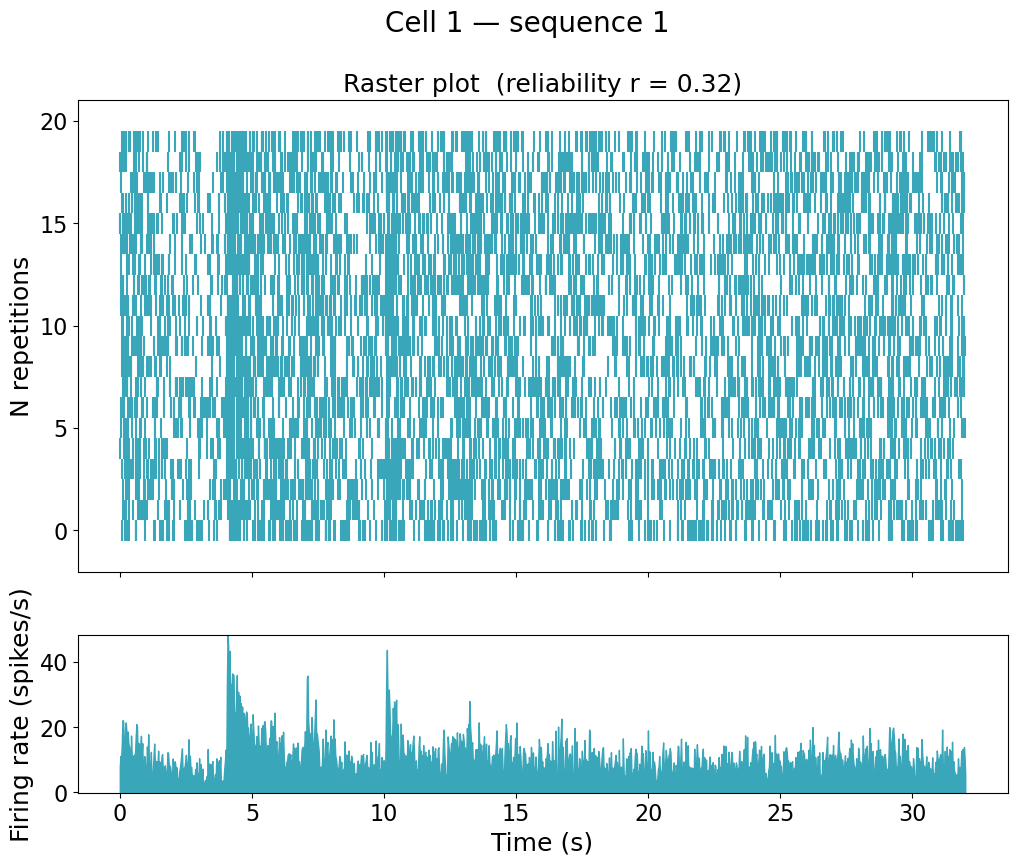

In [7]:
# ---- Pick one cell and one sequence type to display --------------------
cell_to_show = cells[0]                                               # change to any cell id
sequence_to_show = sorted(spikes_per_sequence_dict[cell_to_show])[0]  # change to any sequence key
sequence = spikes_per_sequence_dict[cell_to_show][sequence_to_show]

# Quick way: re-use the helper, just change its options (color, smoothing, fontsize)
fig, axs = plt.subplots(
    2, 1, sharex=True, gridspec_kw={"height_ratios": [3, 1]}, figsize=(12, 9)
)
utils.plot_sequence(
    sequence, ax_rast=axs[0], ax_psth=axs[1], color="#3AA6B9", smoothing=0.2, fontsize=18
)
plt.suptitle(f"Cell {cell_to_show} — sequence {sequence_to_show}", fontsize=20)
plt.show()

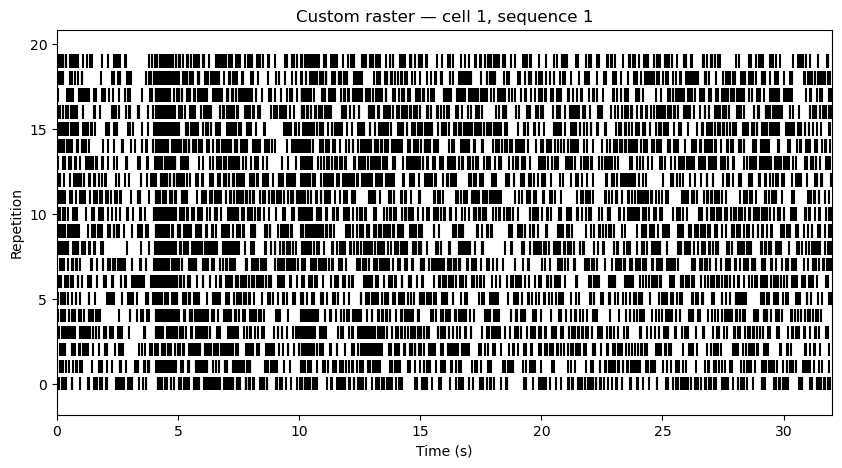

In [8]:
# Example of a fully custom plot: a raster only, with your own styling.
# You are free to use matplotlib however you like from here.
duration = sequence["triggers"]["rng"][1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.eventplot(sequence["raster"], color="black", linelengths=0.8)
ax.set_xlim(0, duration)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Repetition")
ax.set_title(f"Custom raster — cell {cell_to_show}, sequence {sequence_to_show}")
plt.show()

### Show the stimulus above the response

The vec file describes the stimulus frame by frame, and its columns carry stimulus-specific
tracks — e.g. the image index, color, shutter or phase-mask. You can draw the ones you care
about as a **Stimulus** panel above the raster/PSTH, aligned to the same time axis (much like
the chirp stimulus trace).

Choose the columns with `stimulus_columns = [(column_index, "label"), ...]`. Column meanings
depend on how the stimulus was generated, so adapt the indices and labels to your own vec.

To add these tracks to **every** saved figure instead, pass `vec=vec,
stimulus_columns=stimulus_columns` to `save_sequence_figures` in the section above.

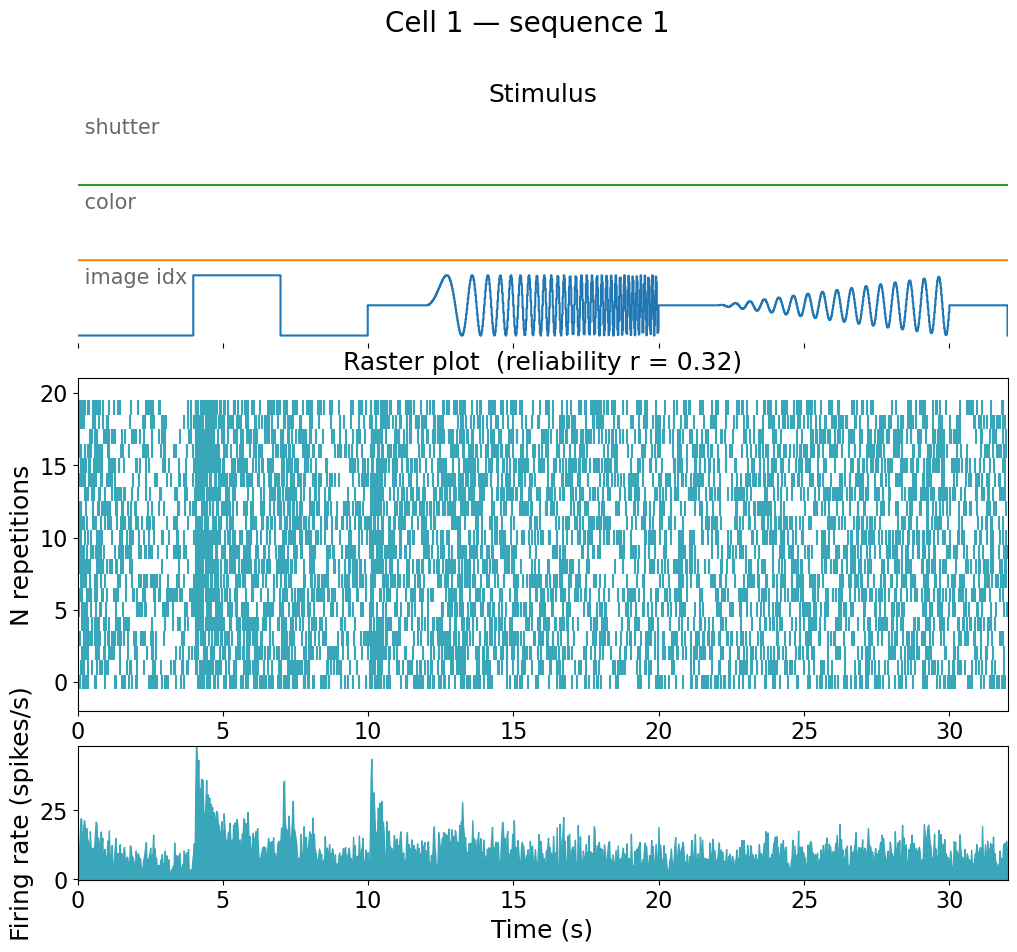

In [9]:
# Which vec columns to show as stimulus tracks, as (column_index, "label") pairs.
# Column meanings are stimulus-specific — adapt these to your vec file.
stimulus_columns = [(1, "image idx"), (2, "color"), (3, "shutter")]

fig = utils.plot_sequence_with_stimulus(
    sequence,               # the cell x sequence chosen above
    vec,                    # the full vec array loaded at the top
    sequence_to_show,       # sequence key, used to pull that sequence's stimulus frames
    columns=stimulus_columns,
    color="#3AA6B9",
    smoothing=0.2,
    fontsize=18,
    n_digit_for_rep=n_digit_for_rep,
)
fig.suptitle(f"Cell {cell_to_show} — sequence {sequence_to_show}", fontsize=20)
plt.show()

## Response reliability (even/odd correlation)

The raster + PSTH plots now show a **reliability score** in the raster title. It is the
**even/odd split-half correlation**: bin each repetition into a PSTH, average the even and
the odd repetitions separately, then correlate the two averages. A cell that responds the
same way every repetition gives r ≈ 1; pure noise gives r ≈ 0. This is an objective sanity
check — e.g. you can decide to discard responses below r = 0.3, instead of "the retina
looks dead after N minutes".

Compute it directly with `utils.even_odd_reliability`:

In [10]:
sequence = spikes_per_sequence_dict[cell_to_show][sequence_to_show]

r = utils.even_odd_reliability(
    sequence["raster"],                   # the per-repetition spike raster
    n_bins=len(sequence["psth"]),         # same bins as the PSTH
    time_range=sequence["triggers"]["rng"],
)
print(f"Cell {cell_to_show}, sequence '{sequence_to_show}': even/odd reliability r = {r:.2f}")

Cell 1, sequence '1': even/odd reliability r = 0.32


### Advanced example — reliability over the course of the recording

A single number hides *when* a cell became unreliable (e.g. the retina degrading late in
the recording). `utils.running_reliability` computes the even/odd reliability in a sliding
window of repetitions (default 10) — the repetitions are in recording-time order. Below we
plot that score next to the raster and shade the repetitions of any low-reliability window
in red, an objective way to spot (and cut) unstable portions of the recording.

*(Needs more repetitions than the window size; otherwise the score is empty.)*

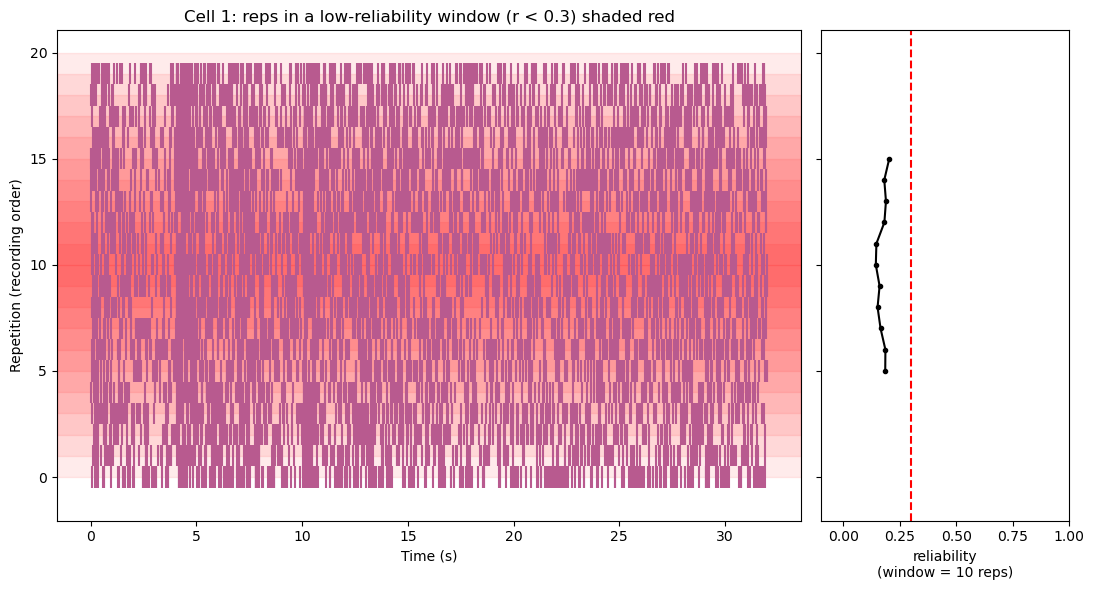

In [11]:
sequence = spikes_per_sequence_dict[cell_to_show][sequence_to_show]
window = 10       # repetitions per sliding window (tunable)
threshold = 0.3   # windows below this are considered unstable

centers, scores = utils.running_reliability(
    sequence["raster"],
    n_bins=len(sequence["psth"]),
    time_range=sequence["triggers"]["rng"],
    window=window,
)

fig, (ax_rast, ax_score) = plt.subplots(
    1, 2, sharey=True, gridspec_kw={"width_ratios": [3, 1]}, figsize=(11, 6)
)
ax_rast.eventplot(sequence["raster"], color="#B85A8F")
ax_rast.set_xlabel("Time (s)")
ax_rast.set_ylabel("Repetition (recording order)")
ax_rast.set_title(f"Cell {cell_to_show}: reps in a low-reliability window (r < {threshold}) shaded red")

# Shade the repetitions that fall inside a below-threshold window.
for center, r in zip(centers, scores):
    if np.isnan(r) or r < threshold:
        ax_rast.axhspan(center - window / 2, center + window / 2, color="red", alpha=0.08)

# Reliability vs repetition, aligned to the raster rows.
ax_score.plot(scores, centers, "-o", color="k", markersize=3)
ax_score.axvline(threshold, color="red", ls="--")
ax_score.set_xlim(-0.1, 1)
ax_score.set_xlabel(f"reliability\n(window = {window} reps)")
plt.tight_layout()
plt.show()

## Appendix — How to create a vec file with the right sequence keys

This notebook needs **one thing** from your vec file: its **last column** must give a *sequence key* to every trigger. The other columns are ignored here.

### The key structure

Each key is a whole number read as two parts:

```
<sequence-type digits><repetition digits>
                      └── the last n_digit_for_rep digits (4 by default)
```

- **Sequence type** (leading digits): *what* was shown — e.g. grating direction, image id, condition number.
- **Repetition** (last `n_digit_for_rep` digits): *which presentation* of that sequence type, zero-padded.

Example with `n_digit_for_rep = 4`, sequence type = grating direction (1–8):

| Direction | Repetition | Key |
|-----------|-----------|-----|
| 1 | 0 | `10000` |
| 1 | 1 | `10001` |
| 2 | 0 | `20000` |
| 8 | 3 | `80003` |

### The rules (important!)

1. **One row per trigger.** The very first line of the file is treated as a header and dropped, so it must *not* be a real trigger.
2. **Same key for every trigger of one repetition.** All triggers making up direction 1, repetition 0 carry the key `10000`.
3. **Start sequence types at 1, not 0.** Keys are stored as whole numbers, so a leading zero is lost (`01000` becomes `1000`). The first digit must be non-zero.
4. **Number repetitions from 0**, zero-padded to `n_digit_for_rep` digits. Repetition `0000` of each sequence type **must exist** — it is used as the timing reference.
5. **Keep every key contiguous.** All triggers sharing a key must form a single uninterrupted block in the file. Never reuse the same key for triggers that appear in two separate places — they would be merged into one (much-too-long) repetition. *(This is the most common mistake.)*
6. **Use the same total width for every key** (e.g. always 5 digits) so the split between sequence type and repetition stays consistent.

Repetitions do **not** need to be in order: you can interleave sequence types and repetitions however your stimulus did, as long as each key stays a single contiguous block (rule 5).

### A worked example to copy

`ressources/add_standard_keys_to_dg_vec.ipynb` builds exactly these keys for an 8-direction, 4-repetition drifting-grating stimulus (each repetition is 12 s = 600 triggers at 50 Hz). Use it as a template: it reads a raw vec, writes the sequence key into the last column following the rules above, and saves the result.